# Benchmark Analysis

Loads benchmark results and produces thesis-quality figures and tables.

**Expected outputs:**
1. Summary heatmap (Gamma by scenario x method)
2. Per-parameter recovery bar charts (membrane vs adaptation)
3. Loss convergence comparison
4. Multi-start distribution (box plots of Gamma)
5. Wall time comparison
6. Firing pattern difficulty ranking
7. LaTeX tables for thesis

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path(".").resolve().parent))

from ADoptEX.benchmark import (
    load_all_results,
    summary_table,
    recovery_table,
    print_table,
    format_latex_table,
)
from ADoptEX.benchmark.scenarios import FULL_PARAMS, MEMBRANE_PARAMS

## Load Results

In [10]:
RESULTS_DIR = Path("results/tonic")
results = load_all_results(RESULTS_DIR)
print(f"Loaded {len(results)} result files")

# Summary table
df = pd.DataFrame(summary_table(results))
df

Loaded 61 result files


,scenario,method,n_runs,mean_gamma,best_gamma,std_gamma,mean_loss,best_loss,mean_wall_time_s,total_wall_time_s
0,tonic_gt00_15pct_membrane,grad_guarino,10,0.131313,0.663978,0.209968,2.034227,0.232079,0.123541,1.235415
1,tonic_gt00_15pct_membrane,grad_vanrossum,10,0.030756,0.134319,0.043426,20.076656,6.590410,0.083637,0.836371
2,tonic_gt00_15pct_membrane,nelder_mead_guarino,10,0.546371,1.000000,0.474389,0.074612,0.000448,1.031551,10.315515
3,tonic_gt00_15pct_membrane,nelder_mead_vanrossum,10,0.899194,1.000000,0.143302,1.584365,0.109897,1.127325,11.273252
4,tonic_gt00_5pct_membrane,grad_guarino,10,0.280490,1.000000,0.409143,3.607479,0.055651,0.119291,1.192906
...,...,...,...,...,...,...,...,...,...,...
56,tonic_gt11_15pct_membrane,nelder_mead_guarino,10,0.388509,1.000000,0.522317,0.214284,0.072300,2.121871,21.218709
57,tonic_gt11_15pct_membrane,nelder_mead_vanrossum,10,0.762715,1.000000,0.315637,2.104905,0.208039,1.137040,11.370401
58,tonic_gt12_15pct_membrane,grad_guarino,10,0.034644,0.161654,0.072954,2.838557,1.144360,0.117048,1.170484
59,tonic_gt12_15pct_membrane,grad_vanrossum,10,0.043125,0.161654,0.070782,4.684037,3.029943,0.074966,0.749656


## 1. Summary Heatmap: Gamma by Scenario x Method

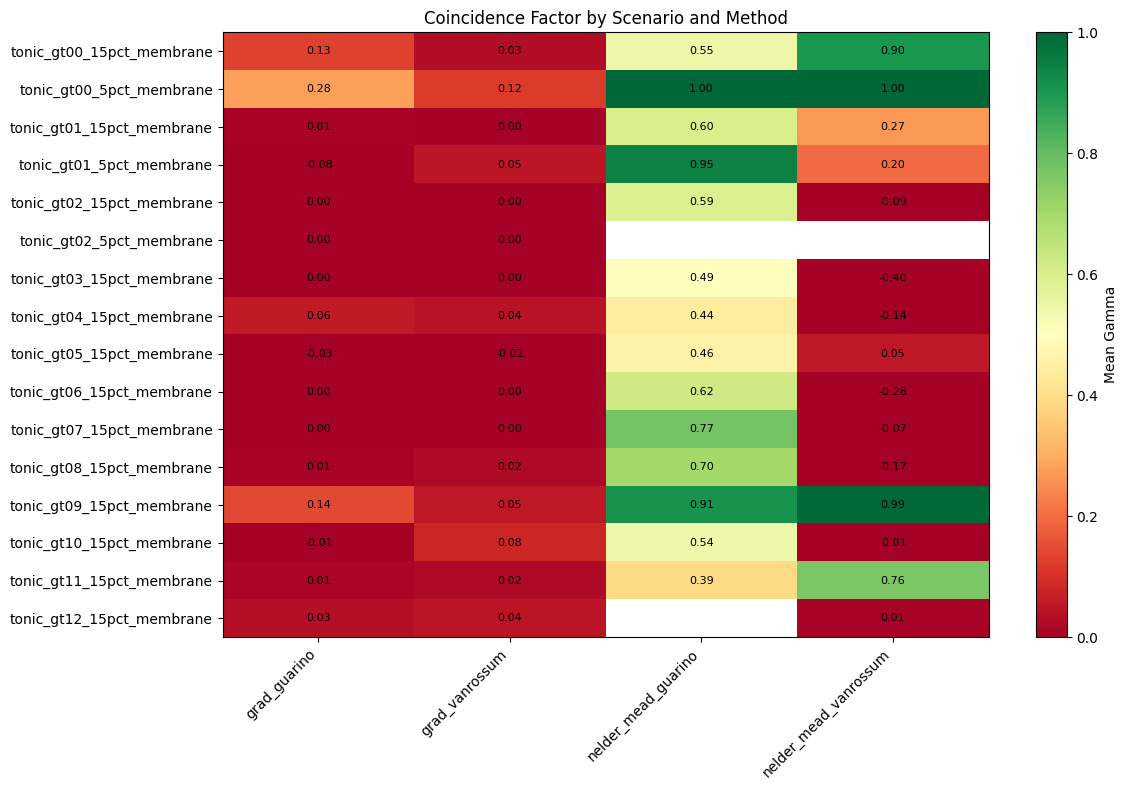

In [11]:
if not df.empty:
    pivot = df.pivot_table(index="scenario", columns="method", values="mean_gamma")
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    # Annotate cells
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, label="Mean Gamma")
    ax.set_title("Coincidence Factor by Scenario and Method")
    plt.tight_layout()
    plt.savefig("gamma_heatmap.pdf", bbox_inches="tight")
    plt.show()

## 2. Per-Parameter Recovery

In [12]:
if not df.empty:
    rec_rows = recovery_table(results, FULL_PARAMS)
    if rec_rows:
        rec_df = pd.DataFrame(rec_rows)
        print_table(rec_rows)
    else:
        print("No recovery data (experimental scenarios only?)")

scenario                  | method                | parameter | n_runs | mean_error_pct | best_error_pct | std_error_pct
------------------------------------------------------------------------------------------------------------------------
tonic_gt00_15pct_membrane | grad_guarino          | C_m       | 5      | 9.2000         | 0.1274         | 8.4768       
tonic_gt00_15pct_membrane | grad_guarino          | g_L       | 5      | 12.7426        | 2.8908         | 13.5882      
tonic_gt00_15pct_membrane | grad_guarino          | E_L       | 5      | 15.0859        | 6.2227         | 7.0791       
tonic_gt00_15pct_membrane | grad_guarino          | v_T       | 5      | 4.5168         | 0.3320         | 3.1155       
tonic_gt00_15pct_membrane | grad_guarino          | delta_T   | 5      | 77.2589        | 3.3472         | 109.4278     
tonic_gt00_15pct_membrane | grad_guarino          | v_reset   | 5      | 10.8484        | 6.4623         | 2.3076       
tonic_gt00_15pct_membrane | grad

## 3. Loss Convergence Comparison

In [13]:
# Plot loss curves for best run of each method on a representative scenario
if results:
    target_scenario = "tonic_15pct_full"
    scenario_results = [r for r in results if r.scenario_name == target_scenario]
    if scenario_results:
        fig, ax = plt.subplots(figsize=(10, 6))
        for sr in scenario_results:
            if sr.best_run and sr.best_run.loss_history:
                ax.semilogy(sr.best_run.loss_history, label=sr.method_name)
        ax.set_xlabel("Epoch / Function Evaluation")
        ax.set_ylabel("Loss")
        ax.set_title(f"Loss Convergence: {target_scenario}")
        ax.legend()
        plt.tight_layout()
        plt.savefig("figures/loss_convergence.pdf", bbox_inches="tight")
        plt.show()

## 4. Multi-Start Distribution (Box Plots)

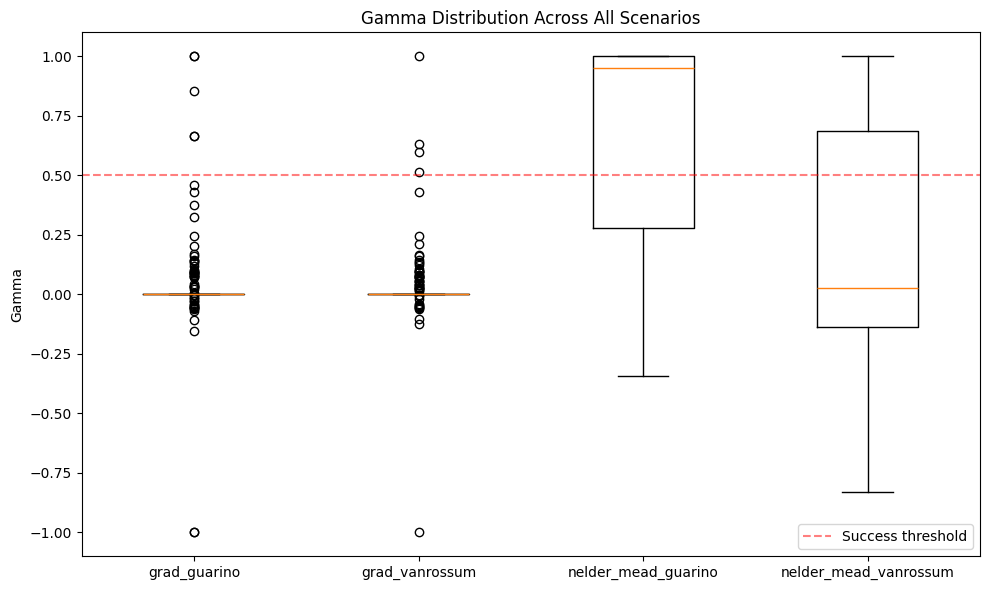

In [14]:
if results:
    # Collect gamma distributions per method
    method_gammas = {}
    for sr in results:
        gammas = [r.gamma for r in sr.runs if r.gamma is not None and not np.isnan(r.gamma)]
        if gammas:
            method_gammas.setdefault(sr.method_name, []).extend(gammas)
    
    if method_gammas:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(method_gammas.values(), tick_labels=method_gammas.keys())
        ax.set_ylabel("Gamma")
        ax.set_title("Gamma Distribution Across All Scenarios")
        ax.axhline(y=0.5, color="r", linestyle="--", alpha=0.5, label="Success threshold")
        ax.legend()
        plt.tight_layout()
        plt.savefig("gamma_boxplot.pdf", bbox_inches="tight")
        plt.show()

## 5. Wall Time Comparison

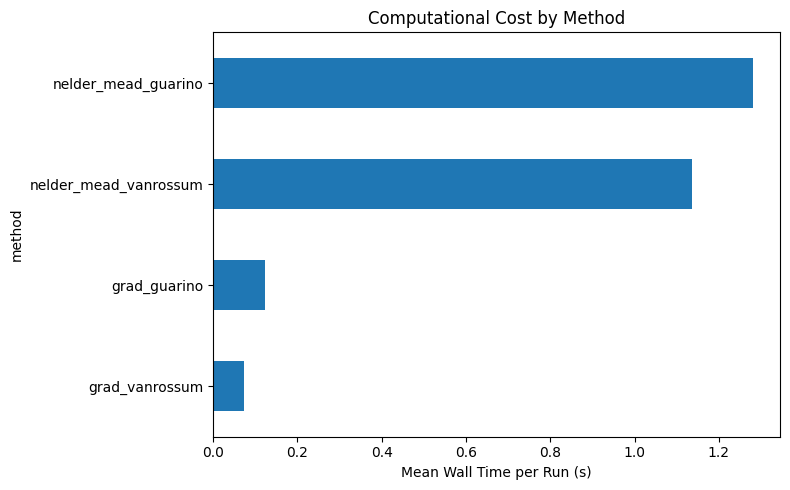

In [15]:
if not df.empty:
    time_df = df.groupby("method")["mean_wall_time_s"].mean().sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    time_df.plot(kind="barh", ax=ax)
    ax.set_xlabel("Mean Wall Time per Run (s)")
    ax.set_title("Computational Cost by Method")
    plt.tight_layout()
    plt.savefig("wall_time.pdf", bbox_inches="tight")
    plt.show()

## 6. LaTeX Tables

In [16]:
if not df.empty:
    # Main results table
    table_rows = summary_table(results)
    latex = format_latex_table(
        [{k: v for k, v in r.items() if k in ("scenario", "method", "mean_gamma", "best_gamma", "mean_loss", "mean_wall_time_s")}
         for r in table_rows],
        caption="Benchmark results: coincidence factor and loss across scenarios and methods"
    )
    print(latex)

\begin{table}[htbp]
\centering
\caption{Benchmark results: coincidence factor and loss across scenarios and methods}
\begin{tabular}{lrrrrr}
\toprule
scenario & method & mean\_gamma & best\_gamma & mean\_loss & mean\_wall\_time\_s \\
\midrule
tonic\_gt00\_15pct\_membrane & grad\_guarino & 0.131 & 0.664 & 2.034 & 0.124 \\
tonic\_gt00\_15pct\_membrane & grad\_vanrossum & 0.031 & 0.134 & 20.077 & 0.084 \\
tonic\_gt00\_15pct\_membrane & nelder\_mead\_guarino & 0.546 & 1.000 & 0.075 & 1.032 \\
tonic\_gt00\_15pct\_membrane & nelder\_mead\_vanrossum & 0.899 & 1.000 & 1.584 & 1.127 \\
tonic\_gt00\_5pct\_membrane & grad\_guarino & 0.280 & 1.000 & 3.607 & 0.119 \\
tonic\_gt00\_5pct\_membrane & grad\_vanrossum & 0.120 & 1.000 & 17.431 & 0.074 \\
tonic\_gt00\_5pct\_membrane & nelder\_mead\_guarino & 1.000 & 1.000 & 0.010 & 1.131 \\
tonic\_gt00\_5pct\_membrane & nelder\_mead\_vanrossum & 1.000 & 1.000 & 0.532 & 1.077 \\
tonic\_gt01\_15pct\_membrane & grad\_guarino & 0.011 & 0.089 & 28786.531 & 0.12